# Importing Necessary Libraries

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

#For the oversampling technique
from imblearn.over_sampling import SMOTE #Synthentic Minority Oversampling Technique
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler # For normalisation
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.multioutput import MultiOutputClassifier


# To ignore the warning
import warnings
warnings.filterwarnings("ignore")

# Data Preprocessing

In [45]:
#loading the dataset
df = pd.read_csv("Occupancy_Estimation.csv")

In [46]:
# display top 5
df.head()

,Date,Time,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
0,2017/12/22,10:49:41,24.94,24.75,24.56,25.38,121,34,53,40,0.08,0.19,0.06,0.06,390,0.769231,0,0,1
1,2017/12/22,10:50:12,24.94,24.75,24.56,25.44,121,33,53,40,0.93,0.05,0.06,0.06,390,0.646154,0,0,1
2,2017/12/22,10:50:42,25.00,24.75,24.50,25.44,121,34,53,40,0.43,0.11,0.08,0.06,390,0.519231,0,0,1
3,2017/12/22,10:51:13,25.00,24.75,24.56,25.44,121,34,53,40,0.41,0.10,0.10,0.09,390,0.388462,0,0,1
4,2017/12/22,10:51:44,25.00,24.75,24.56,25.44,121,34,54,40,0.18,0.06,0.06,0.06,390,0.253846,0,0,1


In [47]:
# display bottom 5
df.tail()

,Date,Time,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
10124,2018/01/11,08:58:07,25.06,25.13,24.69,25.31,6,7,33,22,0.09,0.04,0.06,0.08,345,0.0,0,0,0
10125,2018/01/11,08:58:37,25.06,25.06,24.69,25.25,6,7,34,22,0.07,0.05,0.05,0.08,345,0.0,0,0,0
10126,2018/01/11,08:59:08,25.13,25.06,24.69,25.25,6,7,34,22,0.11,0.05,0.06,0.08,345,0.0,0,0,0
10127,2018/01/11,08:59:39,25.13,25.06,24.69,25.25,6,7,34,22,0.08,0.08,0.10,0.08,345,0.0,0,0,0
10128,2018/01/11,09:00:09,25.13,25.06,24.69,25.25,6,7,34,22,0.08,0.05,0.06,0.08,345,0.0,0,0,0


In [48]:
#fetch the columns
df.columns

Index(['Date', 'Time', 'S1_Temp', 'S2_Temp', 'S3_Temp', 'S4_Temp', 'S1_Light',
       'S2_Light', 'S3_Light', 'S4_Light', 'S1_Sound', 'S2_Sound', 'S3_Sound',
       'S4_Sound', 'S5_CO2', 'S5_CO2_Slope', 'S6_PIR', 'S7_PIR',
       'Room_Occupancy_Count'],
      dtype='object')

In [49]:
#statistical representation of the dataset
df.describe()

,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
count,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.00000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000
mean,25.454012,25.546059,25.056621,25.754125,25.445059,26.01629,34.248494,13.220259,0.168178,0.120066,0.158119,0.103840,460.860401,-0.004830,0.090137,0.079574,0.398559
std,0.351351,0.586325,0.427283,0.356434,51.011264,67.30417,58.400744,19.602219,0.316709,0.266503,0.413637,0.120683,199.964940,1.164990,0.286392,0.270645,0.893633
min,24.940000,24.750000,24.440000,24.940000,0.000000,0.00000,0.000000,0.000000,0.060000,0.040000,0.040000,0.050000,345.000000,-6.296154,0.000000,0.000000,0.000000
25%,25.190000,25.190000,24.690000,25.440000,0.000000,0.00000,0.000000,0.000000,0.070000,0.050000,0.060000,0.060000,355.000000,-0.046154,0.000000,0.000000,0.000000
50%,25.380000,25.380000,24.940000,25.750000,0.000000,0.00000,0.000000,0.000000,0.080000,0.050000,0.060000,0.080000,360.000000,0.000000,0.000000,0.000000,0.000000
75%,25.630000,25.630000,25.380000,26.000000,12.000000,14.00000,50.000000,22.000000,0.080000,0.060000,0.070000,0.100000,465.000000,0.000000,0.000000,0.000000,0.000000
max,26.380000,29.000000,26.190000,26.560000,165.000000,258.00000,280.000000,74.000000,3.880000,3.440000,3.670000,3.400000,1270.000000,8.980769,1.000000,1.000000,3.000000


In [50]:
#checking the dtypes
df.dtypes

Date                     object
Time                     object
S1_Temp                 float64
S2_Temp                 float64
S3_Temp                 float64
S4_Temp                 float64
S1_Light                  int64
S2_Light                  int64
S3_Light                  int64
S4_Light                  int64
S1_Sound                float64
S2_Sound                float64
S3_Sound                float64
S4_Sound                float64
S5_CO2                    int64
S5_CO2_Slope            float64
S6_PIR                    int64
S7_PIR                    int64
Room_Occupancy_Count      int64
dtype: object

In [51]:
#converting the date and time into the pandas date and time format
df['Date'] = pd.to_datetime(df['Date'])
df['Time'] = pd.to_timedelta(df['Time'])

In [52]:
df.dtypes

Date                     datetime64[ns]
Time                    timedelta64[ns]
S1_Temp                         float64
S2_Temp                         float64
S3_Temp                         float64
S4_Temp                         float64
S1_Light                          int64
S2_Light                          int64
S3_Light                          int64
S4_Light                          int64
S1_Sound                        float64
S2_Sound                        float64
S3_Sound                        float64
S4_Sound                        float64
S5_CO2                            int64
S5_CO2_Slope                    float64
S6_PIR                            int64
S7_PIR                            int64
Room_Occupancy_Count              int64
dtype: object

In [53]:
#checking if there is any null values or not
df.isnull().any().sum()

np.int64(0)

# Features Extraction

In [55]:
DateTime = df["Date"] + df["Time"]
df.insert(loc = 0, column = "Date_Time", value = DateTime)

In [56]:

weekday = df['Date_Time'].dt.weekday + 1
df.insert(loc = 0, column = "Day of week", value = weekday)

dayhour = df['Date_Time'].dt.hour + 1
df.insert(loc = 0, column = "Hour of day", value = dayhour)

In [57]:
temp_mean = df.iloc[:,5:9].mean(axis=1)
df.insert(loc = 0, column = "Mean_Temperature", value = temp_mean)

light_mean = df.iloc[:,9:13].mean(axis=1)
df.insert(loc = 0, column = "Mean_light", value = light_mean)

sound_mean = df.iloc[:,13:17].mean(axis=1)
df.insert(loc = 0, column = "Mean_sound", value = sound_mean)

In [58]:
footsteps_sound = ((df['S1_Sound']+df['S2_Sound']+df['S3_Sound']+df['S4_Sound'])/4)*((df['S6_PIR']+df['S7_PIR']+0.1)/2)
df.insert(loc = 16, column = "Footsteps_Sound", value = footsteps_sound)

pir_level = df['S6_PIR']+df['S7_PIR']
df.insert(loc = 17, column = "PIR_Level", value = pir_level)

In [59]:
rolling = df['S5_CO2'].rolling(window=10)
rolling_mean = rolling.mean()
df.insert(loc = 0, column = "MA_CO2", value = rolling_mean)
     

In [60]:
rolling = df['S5_CO2'].rolling(window=10)
rolling_variance = rolling.var()
df.insert(loc = 0, column = "MV_CO2", value = rolling_variance)
     

In [61]:
df.head(10)

,MV_CO2,MA_CO2,Mean_sound,Mean_light,Mean_Temperature,Hour of day,Day of week,Date_Time,Date,Time,...,PIR_Level,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
0,NaN,NaN,23.3175,58.345,24.9075,11,5,2017-12-22 10:49:41,2017-12-22,0 days 10:49:41,...,0,0.08,0.19,0.06,0.06,390,0.769231,0,0,1
1,NaN,NaN,23.4950,58.110,24.9225,11,5,2017-12-22 10:50:12,2017-12-22,0 days 10:50:12,...,0,0.93,0.05,0.06,0.06,390,0.646154,0,0,1
2,NaN,NaN,23.3850,58.360,24.9225,11,5,2017-12-22 10:50:42,2017-12-22,0 days 10:50:42,...,0,0.43,0.11,0.08,0.06,390,0.519231,0,0,1
3,NaN,NaN,23.3775,58.360,24.9375,11,5,2017-12-22 10:51:13,2017-12-22,0 days 10:51:13,...,0,0.41,0.10,0.10,0.09,390,0.388462,0,0,1
4,NaN,NaN,23.5600,58.610,24.9375,11,5,2017-12-22 10:51:44,2017-12-22,0 days 10:51:44,...,0,0.18,0.06,0.06,0.06,390,0.253846,0,0,1
5,NaN,NaN,23.5475,58.610,24.9525,11,5,2017-12-22 10:52:14,2017-12-22,0 days 10:52:14,...,0,0.13,0.06,0.06,0.07,390,0.165385,0,0,1
6,NaN,NaN,23.9275,58.360,24.9375,11,5,2017-12-22 10:52:45,2017-12-22,0 days 10:52:45,...,1,1.39,0.32,0.43,0.06,390,0.076923,1,0,1
7,NaN,NaN,23.7875,58.610,24.9525,11,5,2017-12-22 10:53:15,2017-12-22,0 days 10:53:15,...,0,0.09,0.06,0.09,0.05,390,-0.011538,0,0,1
8,NaN,NaN,24.7850,59.625,24.9675,11,5,2017-12-22 10:53:46,2017-12-22,0 days 10:53:46,...,0,0.09,0.05,0.06,0.13,390,-0.100000,0,0,1
9,0.0,390.0,26.1200,54.375,24.9675,11,5,2017-12-22 10:54:17,2017-12-22,0 days 10:54:17,...,2,3.84,0.64,0.48,0.39,390,-0.188462,1,1,1


In [62]:
df = df.dropna()
df = df.reset_index()
df = df.drop(['index'], axis = 1)

In [63]:
df.head()

,MV_CO2,MA_CO2,Mean_sound,Mean_light,Mean_Temperature,Hour of day,Day of week,Date_Time,Date,Time,...,PIR_Level,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
0,0.0,390.0,26.1200,54.375,24.9675,11,5,2017-12-22 10:54:17,2017-12-22,0 days 10:54:17,...,2,3.84,0.64,0.48,0.39,390,-0.188462,1,1,1
1,0.0,390.0,25.6275,59.860,24.9675,11,5,2017-12-22 10:54:47,2017-12-22,0 days 10:54:47,...,2,2.20,0.31,0.33,0.21,390,-0.276923,1,1,1
2,0.0,390.0,25.3875,60.125,24.9825,11,5,2017-12-22 10:55:18,2017-12-22,0 days 10:55:18,...,1,0.42,0.13,0.14,0.09,390,-0.365385,1,0,1
3,0.0,390.0,25.0900,60.125,25.0175,11,5,2017-12-22 10:55:49,2017-12-22,0 days 10:55:49,...,1,0.21,0.15,0.07,0.06,390,-0.453846,1,0,1
4,0.0,390.0,25.7175,60.140,25.0150,11,5,2017-12-22 10:56:19,2017-12-22,0 days 10:56:19,...,1,1.66,0.21,0.12,0.09,390,-0.542308,1,0,1


# Data Visualisation

In [65]:
df = df.loc[df['Date'] =='2017/12/22']

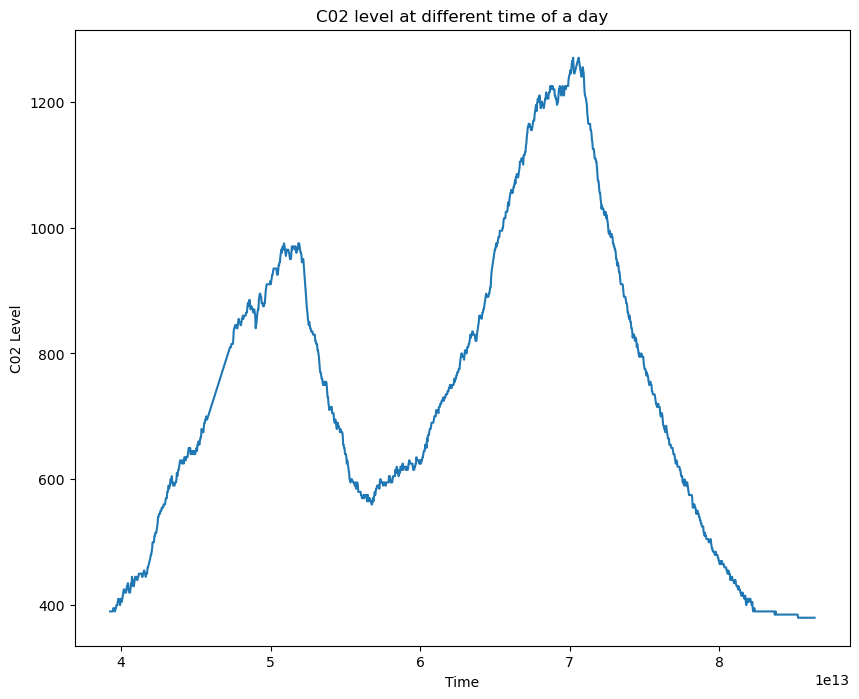

In [66]:
plt.figure(figsize=(10, 8))
sns.lineplot(x = 'Time', y ='S5_CO2', data =df)
plt.xlabel('Time')   
plt.ylabel('C02 Level')
plt.title('C02 level at different time of a day')
plt.show()

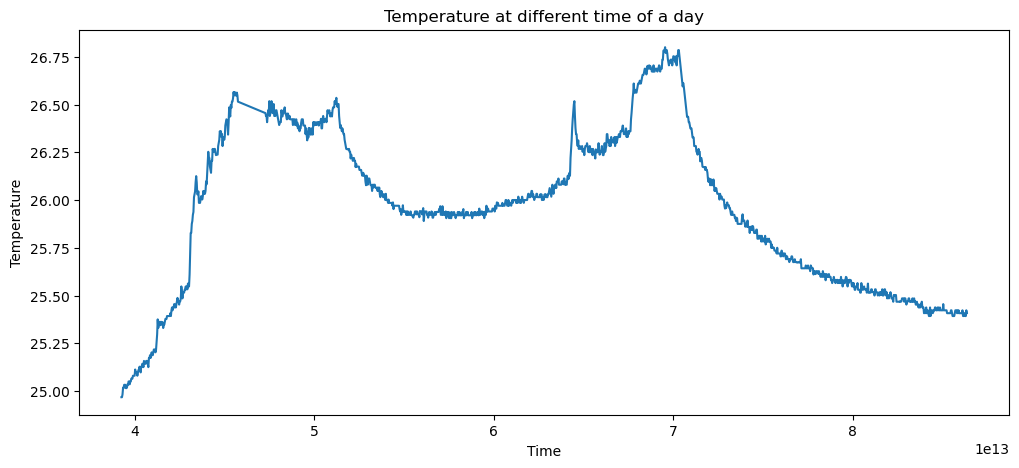

In [67]:
plt.figure( figsize = (12, 5)) 
sns.lineplot(x = 'Time', y = 'Mean_Temperature', data = df) 
plt.xlabel('Time')   
plt.ylabel('Temperature')
plt.title('Temperature at different time of a day')
plt.show()

In [68]:
#axis = 1 instead of creating a new dataframe it will modifying to the existing one
df = df.drop(['Date', 'Time', 'Date_Time'], axis = 1)

In [69]:
df.head()

,MV_CO2,MA_CO2,Mean_sound,Mean_light,Mean_Temperature,Hour of day,Day of week,S1_Temp,S2_Temp,S3_Temp,...,PIR_Level,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
0,0.0,390.0,26.1200,54.375,24.9675,11,5,25.00,24.81,24.56,...,2,3.84,0.64,0.48,0.39,390,-0.188462,1,1,1
1,0.0,390.0,25.6275,59.860,24.9675,11,5,25.06,24.81,24.56,...,2,2.20,0.31,0.33,0.21,390,-0.276923,1,1,1
2,0.0,390.0,25.3875,60.125,24.9825,11,5,25.06,24.81,24.56,...,1,0.42,0.13,0.14,0.09,390,-0.365385,1,0,1
3,0.0,390.0,25.0900,60.125,25.0175,11,5,25.06,24.88,24.63,...,1,0.21,0.15,0.07,0.06,390,-0.453846,1,0,1
4,0.0,390.0,25.7175,60.140,25.0150,11,5,25.06,24.81,24.63,...,1,1.66,0.21,0.12,0.09,390,-0.542308,1,0,1


# Oversampling Technique

## SMOTE (Synthetic Minority Over-sampling Technique) balances imbalanced datasets by generating completely new, synthetic data points for the minority class rather than simply duplicating existing ones. It achieves this by interpolating (drawing lines) between existing minority class samples and their nearest neighbors

In [71]:
class_count = df['Room_Occupancy_Count'].value_counts()

labels = [0, 1, 2, 3]

classes = [0]* len(class_count)
for index in range(len(class_count)):
    classes[index] = df[df['Room_Occupancy_Count'] == labels[index]]
for index in range(len(classes)):
    print("class" + str(index)+":",classes[index].shape)

class0: (637, 26)
class1: (196, 26)
class2: (257, 26)
class3: (363, 26)


In [72]:
df = df.values

In [73]:
features, label = df[:, :-1], df[:, -1]

In [77]:
feature = features.astype("float32")

In [79]:
feature

array([[ 0.0000000e+00,  3.9000000e+02,  2.6120001e+01, ...,
        -1.8846154e-01,  1.0000000e+00,  1.0000000e+00],
       [ 0.0000000e+00,  3.9000000e+02,  2.5627501e+01, ...,
        -2.7692309e-01,  1.0000000e+00,  1.0000000e+00],
       [ 0.0000000e+00,  3.9000000e+02,  2.5387501e+01, ...,
        -3.6538461e-01,  1.0000000e+00,  0.0000000e+00],
       ...,
       [ 0.0000000e+00,  3.8000000e+02,  2.9999999e-02, ...,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 0.0000000e+00,  3.8000000e+02,  2.9999999e-02, ...,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 0.0000000e+00,  3.8000000e+02,  2.9999999e-02, ...,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00]], dtype=float32)

In [80]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [83]:
#Splitting the data into training and test
x_train, x_test, y_train, y_test = train_test_split(features,label,test_size = 0.20,random_state=132)

In [84]:
print(f"X Train: {x_train.shape}")
print(f"X Test: {x_test.shape}")
print(f"Y Train: {y_train.shape}")
print(f"Y Test: {y_test.shape}")

X Train: (1162, 25)
X Test: (291, 25)
Y Train: (1162,)
Y Test: (291,)


In [85]:
oversample = SMOTE()
x_train, y_train = oversample.fit_resample(x_train, y_train)

counter = Counter(y_train)
for Class,value in counter.items():
	percentage = value / len(y_train) * 100
	print('Class=%d, n=%d (%.3f%%)' % (Class, value, percentage))

Class=2, n=512 (25.000%)
Class=0, n=512 (25.000%)
Class=3, n=512 (25.000%)
Class=1, n=512 (25.000%)


# Machine Learning Algorithm

## K-NN (K-Nearest Neighbor)
## Logistic Regression
## Support Vector Machine
## Naive Bayes

In [88]:
model = KNeighborsClassifier(n_neighbors = 50) #how many neighbors you want to use
model.fit(x_train, y_train)
pred = model.predict(x_test)

In [94]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print('Accuracy: ', accuracy_score(y_test, pred))
print('Precision: ', precision_score(y_test, pred, average='macro'))
print('Recall: ', recall_score(y_test, pred, average='macro'))
print('f1-score: ', f1_score(y_test, pred, average='macro'))

Accuracy:  0.9725085910652921
Precision:  0.9661531279178338
Recall:  0.9666585505943462
f1-score:  0.9660491162864125


In [95]:
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import label_binarize

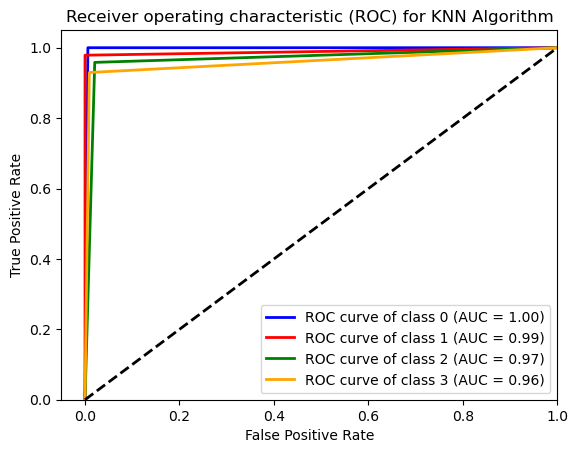

In [96]:
y_train_1 = label_binarize(y_train, classes=[0, 1, 2, 3])
y_test_1 = label_binarize(y_test, classes=[0, 1, 2, 3])
pred = label_binarize(pred, classes=[0, 1, 2, 3])
n_classes = 4 #since, it is multi-class classification

fpr = dict()
tpr = dict()
roc_auc = dict()
lw=2
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_1[:, i], pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
colors = ['blue', 'red', 'green', 'orange']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (AUC = {1:0.2f})'
             ''.format(i, roc_auc[i]))
plt.plot([0, 1], [0, 1], 'k--', lw=lw)
plt.xlim([-0.05, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic (ROC) for KNN Algorithm')
plt.legend(loc="lower right")
plt.show()
     

# Logistic Regression

In [98]:
model = LogisticRegression(solver = 'lbfgs', multi_class = 'auto')
model.fit(x_train, y_train)
pred = model.predict(x_test)

In [99]:

print('Accuracy: ', accuracy_score(y_test, pred))
print('Precision: ', precision_score(y_test, pred, average='macro'))
print('Recall: ', recall_score(y_test, pred, average='macro'))
print('f1-score: ', f1_score(y_test, pred, average='macro'))

Accuracy:  0.9690721649484536
Precision:  0.961707032602555
Recall:  0.9631374238337829
f1-score:  0.9618230583975458


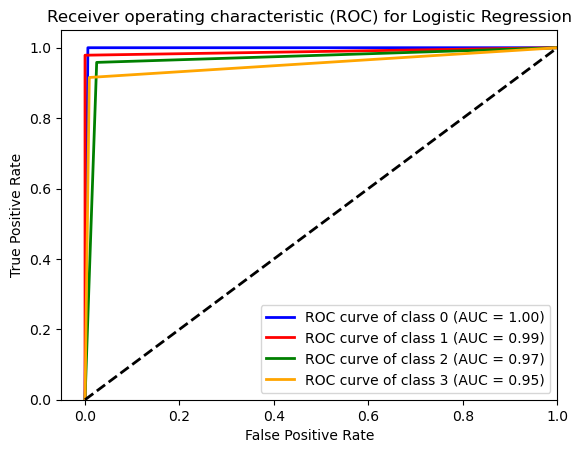

In [101]:
y_train_2 = label_binarize(y_train, classes=[0, 1, 2, 3])
y_test_2 = label_binarize(y_test, classes=[0, 1, 2, 3])
pred = label_binarize(pred, classes=[0, 1, 2, 3])
n_classes = 4

fpr = dict()
tpr = dict()
roc_auc = dict()
lw=2
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_2[:, i], pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
colors = ['blue', 'red', 'green', 'orange']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (AUC = {1:0.2f})'
             ''.format(i, roc_auc[i]))
plt.plot([0, 1], [0, 1], 'k--', lw=lw)
plt.xlim([-0.05, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic (ROC) for Logistic Regression')
plt.legend(loc="lower right")
plt.show()

# Support Vector Machine

In [102]:
model = SVC(kernel = 'rbf')
model.fit(x_train, y_train)
pred = model.predict(x_test)

In [103]:

print(accuracy_score(y_test, pred))
print(precision_score(y_test, pred, average='macro'))
print(recall_score(y_test, pred, average='macro'))
print(f1_score(y_test, pred, average='macro'))

0.9656357388316151
0.9575746965452848
0.9579290905004495
0.9574014889337493


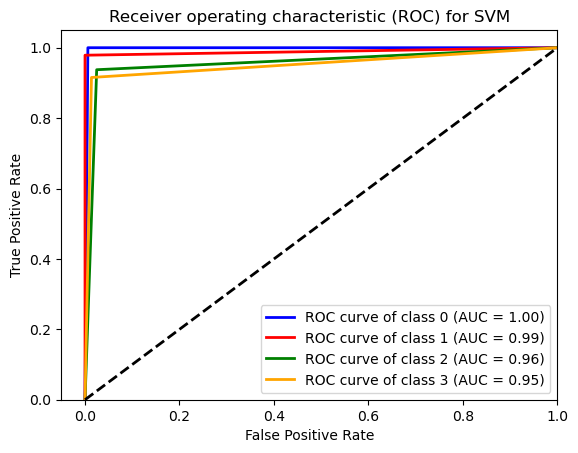

In [104]:
y_train = label_binarize(y_train, classes=[0, 1, 2, 3])
y_test = label_binarize(y_test, classes=[0, 1, 2, 3])
pred = label_binarize(pred, classes=[0, 1, 2, 3])
n_classes = 4

fpr = dict()
tpr = dict()
roc_auc = dict()
lw=2
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
colors = ['blue', 'red', 'green', 'orange']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (AUC = {1:0.2f})'
             ''.format(i, roc_auc[i]))
plt.plot([0, 1], [0, 1], 'k--', lw=lw)
plt.xlim([-0.05, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic (ROC) for SVM')
plt.legend(loc="lower right")
plt.show()
     